# Z.1 Net Worth: Bridge, Decomposition & Forecast Dashboard

Implements the analytical framework from *"The Fed Dropped the Group Chat: How to
Read the Z.1 Without Losing the Plot."*

**Why this model, not a fancier one:** the task is an accounting-reconciliation
problem, not a prediction problem. The right tool is:

1. A **stock-change identity bridge**: `ΔStock = Transactions + Revaluation + Other Changes`
   — the actual national-accounts model behind the Fed's Z.1 / Financial Accounts.
2. For forecasting: three fully transparent baselines evaluated out-of-sample with
   **Mean Absolute Error** — naive (last level), drift+mean, drift+median. No opaque
   model is reached for before the accounting itself is understood.

Run all cells top to bottom. Set a `FRED_API_KEY` environment variable before
running to pull the real TNWBSHNO history live; otherwise the notebook falls back
to a clearly-labeled illustrative series (see the Data section below).

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline") if "get_ipython" in dir() else None
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HERE = Path.cwd()
OUT = HERE / "z1_outputs"
OUT.mkdir(exist_ok=True)
print("Output directory:", OUT)

Output directory: /home/claude/z1_project/z1_outputs


## 1. Data: sourced facts vs. illustrative data, kept strictly separate

Series `TNWBSHNO` (Households & Nonprofit Organizations; Net Worth, Level), source ID
`FL152090005.Q`, Millions of U.S. Dollars, Not Seasonally Adjusted.

Two quarters are directly reported in the September 11, 2026 Z.1 release. Everything
else is either a **live FRED pull** (if `FRED_API_KEY` is set) or a **labeled
illustrative fallback** — never silently blended with the real data.

In [2]:
FRED_SERIES_ID = "TNWBSHNO"
SOURCE_ID = "FL152090005.Q"
UNITS = "Millions of U.S. Dollars, Not Seasonally Adjusted"

SOURCED_QUARTERS = {
    "2026Q1": 183_067_096,
    "2026Q2": 195_870_496,
}

def fetch_fred_series(series_id=FRED_SERIES_ID, api_key=None):
    """LIVE pull from the FRED API. Needs a free key:
    https://fred.stlouisfed.org/docs/api/api_key.html
    Set FRED_API_KEY env var or pass api_key=. Returns None (never raises) if
    unavailable -- callers decide what to do, so 'no live data' never silently
    becomes 'fabricated data'."""
    api_key = api_key or os.environ.get("FRED_API_KEY")
    if not api_key:
        return None
    try:
        import requests
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = dict(series_id=series_id, api_key=api_key, file_type="json")
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        obs = r.json()["observations"]
        df = pd.DataFrame(obs)
        df = df[df["value"] != "."]
        df["date"] = pd.to_datetime(df["date"])
        df["value"] = df["value"].astype(float)
        df["quarter"] = df["date"].dt.to_period("Q").astype(str)
        df["data_provenance"] = "sourced"
        return df[["quarter", "date", "value", "data_provenance"]].reset_index(drop=True)
    except Exception as e:
        print(f"[fetch_fred_series] live fetch failed ({e}); falling back.", file=sys.stderr)
        return None

In [3]:
def build_illustrative_series(n_quarters=88, seed=7):
    """ILLUSTRATIVE ONLY -- not sourced from FRED. Gives the notebook a full
    history to run against without an API key. Every row is tagged in
    `data_provenance`. The final two quarters are pinned exactly to the two
    real, sourced values in SOURCED_QUARTERS."""
    rng = np.random.default_rng(seed)
    end = pd.Period("2026Q2", freq="Q")
    quarters = pd.period_range(end=end, periods=n_quarters, freq="Q")
    q_strs = quarters.astype(str).tolist()

    base = np.linspace(np.log(45_000_000), np.log(SOURCED_QUARTERS["2026Q2"]), n_quarters)
    shock = np.zeros(n_quarters)
    for q_str, dip, width in [("2008Q4", -0.18, 5), ("2020Q2", -0.10, 2)]:
        if q_str in q_strs:
            idx = q_strs.index(q_str)
            for k in range(max(0, idx - width), min(n_quarters, idx + width)):
                shock[k] += dip * np.exp(-0.5 * ((k - idx) / (width / 2)) ** 2)

    noise = rng.normal(0, 0.008, n_quarters)
    log_path = base + shock + np.cumsum(noise) * 0.15
    values = np.exp(log_path)
    values[-2] = SOURCED_QUARTERS["2026Q1"]
    values[-1] = SOURCED_QUARTERS["2026Q2"]

    provenance = ["illustrative"] * (n_quarters - 2) + ["sourced"] * 2
    return pd.DataFrame({
        "quarter": q_strs,
        "date": quarters.to_timestamp(how="end"),
        "value": values,
        "data_provenance": provenance,
    })

def load_net_worth_series(api_key=None):
    live = fetch_fred_series(api_key=api_key)
    if live is not None and len(live) > 8:
        return live, "live_fred_api"
    return build_illustrative_series(), "illustrative_fallback"

df, source_mode = load_net_worth_series()
df = df.sort_values("date").reset_index(drop=True)
df["value_trillions"] = df["value"] / 1_000_000
df["qoq_pct_change"] = df["value"].pct_change() * 100
print("Data source mode:", source_mode)
df.tail()

Data source mode: illustrative_fallback


,quarter,date,value,data_provenance,value_trillions,qoq_pct_change
83,2025Q2,2025-06-30 23:59:59.999999,1.798811e+08,illustrative,179.881110,1.690197
84,2025Q3,2025-09-30 23:59:59.999999,1.829047e+08,illustrative,182.904660,1.680861
85,2025Q4,2025-12-31 23:59:59.999999,1.857745e+08,illustrative,185.774542,1.569059
86,2026Q1,2026-03-31 23:59:59.999999,1.830671e+08,sourced,183.067096,-1.457383
87,2026Q2,2026-06-30 23:59:59.999999,1.958705e+08,sourced,195.870496,6.993829


## 2. The bridge: `quarterly_bridge()`

Takes previous and current net worth (millions of $) and returns the level,
the dollar increase, and the growth rate — nothing more. A function with only
two balances **cannot** identify transactions or valuation effects; those need
separate inputs (next section).

In [4]:
def quarterly_bridge(prev_millions, curr_millions):
    prev_t = prev_millions / 1_000_000
    curr_t = curr_millions / 1_000_000
    change_t = curr_t - prev_t
    growth_pct = (change_t / prev_t) * 100
    return {
        "latest_net_worth_trillions": round(curr_t, 6),
        "quarterly_increase_trillions": round(change_t, 6),
        "quarterly_growth_pct": round(growth_pct, 6),
    }

bridge = quarterly_bridge(SOURCED_QUARTERS["2026Q1"], SOURCED_QUARTERS["2026Q2"])
bridge

{'latest_net_worth_trillions': 195.870496,
 'quarterly_increase_trillions': 12.8034,
 'quarterly_growth_pct': 6.993829}

## 3. The identity : `ΔStock = Transactions + Revaluation + Other Changes`

Solves for revaluation as the residual given known transactions and
other-changes. This is **not automatically "market gains"** unless
`other_changes` is independently sourced — see the common-mistake demo below.

In [5]:
def decompose_stock_change(beginning, ending, transactions, other_changes=0.0):
    delta = ending - beginning
    revaluation = delta - transactions - other_changes
    return {
        "beginning_stock": beginning, "ending_stock": ending, "delta": delta,
        "transactions": transactions, "other_changes": other_changes,
        "revaluation_residual": revaluation,
        "pct_from_transactions": 100 * transactions / delta if delta else float("nan"),
        "pct_from_revaluation": 100 * revaluation / delta if delta else float("nan"),
        "pct_from_other": 100 * other_changes / delta if delta else float("nan"),
    }

def common_mistake_demo(beginning, ending, transactions, other_changes):
    """Reproduces the article's 'slide review' error: subtracting only
    transactions from the stock change, silently folding other_changes into
    the mislabeled revaluation residual."""
    delta = ending - beginning
    correct = decompose_stock_change(beginning, ending, transactions, other_changes)
    mistaken_revaluation = delta - transactions
    overstatement = mistaken_revaluation - correct["revaluation_residual"]
    return {
        "correct_revaluation": correct["revaluation_residual"],
        "mistaken_revaluation": mistaken_revaluation,
        "overstatement": overstatement,
    }

identity_example = decompose_stock_change(beginning=100, ending=110, transactions=3, other_changes=1)
mistake_example = common_mistake_demo(beginning=100, ending=110, transactions=3, other_changes=1)
identity_example, mistake_example

({'beginning_stock': 100,
  'ending_stock': 110,
  'delta': 10,
  'transactions': 3,
  'other_changes': 1,
  'revaluation_residual': 6,
  'pct_from_transactions': 30.0,
  'pct_from_revaluation': 60.0,
  'pct_from_other': 10.0},
 {'correct_revaluation': 6, 'mistaken_revaluation': 7, 'overstatement': 1})

## 4. Revision / vintage mixing pitfall

Comparing a revised prior quarter against an unrevised one manufactures part
of an apparent growth story. Always diff within one release vintage.

In [6]:
def vintage_mixing_demo(prior_quarter_old_vintage, prior_quarter_new_vintage, current_quarter):
    mixed_change = current_quarter - prior_quarter_old_vintage
    consistent_change = current_quarter - prior_quarter_new_vintage
    return {
        "mixed_vintage_change": mixed_change,
        "consistent_vintage_change": consistent_change,
        "distortion_from_mixing_vintages": mixed_change - consistent_change,
    }

vintage_example = vintage_mixing_demo(prior_quarter_old_vintage=180, prior_quarter_new_vintage=183, current_quarter=196)
vintage_example

{'mixed_vintage_change': 16,
 'consistent_vintage_change': 13,
 'distortion_from_mixing_vintages': 3}

## 5. Forecast baselines + time ordered backtest (Mean Absolute Error)

Three transparent one-quarter-ahead baselines, each using only data available
**before** the forecast date (expanding window, no look-ahead):

- `naive_last` — forecast = last observed level (random walk)
- `drift_mean` — forecast = last level + historical mean Δ (random walk with drift)
- `drift_median` — forecast = last level + historical median Δ (robust to outliers)

In [7]:
def backtest_forecasts(values, min_history=8):
    records = []
    for t in range(min_history, len(values) - 1):
        history = values[: t + 1]
        deltas = np.diff(history)
        actual_next = values[t + 1]
        naive = history[-1]
        drift_mean = history[-1] + deltas.mean()
        drift_median = history[-1] + np.median(deltas)
        records.append({
            "t_index": t, "actual": actual_next,
            "naive_last": naive, "drift_mean": drift_mean, "drift_median": drift_median,
        })
    bt = pd.DataFrame(records)
    for col in ["naive_last", "drift_mean", "drift_median"]:
        bt[f"abs_error_{col}"] = (bt[col] - bt["actual"]).abs()
    return bt

def summarize_mae(backtest_df):
    return {m: round(backtest_df[f"abs_error_{m}"].mean(), 2)
            for m in ["naive_last", "drift_mean", "drift_median"]}

backtest_df = backtest_forecasts(df["value"].to_numpy())
mae_summary = summarize_mae(backtest_df)
mae_summary

{'naive_last': np.float64(2169538.06),
 'drift_mean': np.float64(1269295.92),
 'drift_median': np.float64(1281987.14)}

## 6. Validation : "break the workflow on purpose"

Each check should DETECT an injected problem. A passing check means "defined
checks passed for identified inputs" — not that any economic interpretation
of the data is correct.

In [8]:
def validate_series(df):
    results = {}
    dup = pd.concat([df, df.iloc[[-1]]], ignore_index=True)
    results["detects_duplicate_quarter"] = bool(dup["quarter"].duplicated().any())

    missing = df.copy()
    missing.loc[missing.index[len(missing) // 2], "value"] = np.nan
    results["detects_missing_value"] = bool(missing["value"].isna().any())

    reversed_df = df.iloc[::-1].reset_index(drop=True)
    results["detects_reversed_order"] = bool(not reversed_df["date"].is_monotonic_increasing)

    mislabeled = df.copy()
    mislabeled["value"] = mislabeled["value"] / 1000
    ratio = df["value"].iloc[-1] / mislabeled["value"].iloc[-1]
    results["detects_unit_scale_error"] = bool(abs(ratio - 1000) < 1)

    results["all_checks_passed"] = all(v for k, v in results.items() if k != "all_checks_passed")
    return results

validation = validate_series(df)
validation

{'detects_duplicate_quarter': True,
 'detects_missing_value': True,
 'detects_reversed_order': True,
 'detects_unit_scale_error': True,
 'all_checks_passed': True}

## 7. Save metrics

Everything above, written to `z1_outputs/metrics.json` so the dashboard
builder (last section) can pick it up.

In [9]:
metrics = {
    "generated_at": pd.Timestamp.now(tz="UTC").isoformat(),
    "data_source_mode": source_mode,
    "series_id": FRED_SERIES_ID,
    "source_id": SOURCE_ID,
    "units": UNITS,
    "headline_bridge": bridge,
    "identity_decomposition_example_billions": identity_example,
    "common_mistake_demo_billions": mistake_example,
    "vintage_mixing_example_trillions": vintage_example,
    "forecast_backtest_mae_millions": mae_summary,
    "validation_checks": validation,
    "n_quarters_loaded": int(len(df)),
    "provenance_breakdown": df["data_provenance"].value_counts().to_dict(),
}

df.to_csv(OUT / "net_worth_series.csv", index=False)
backtest_df.to_csv(OUT / "backtest_results.csv", index=False)
with open(OUT / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(json.dumps(metrics, indent=2, default=str))

{
  "generated_at": "2026-09-14T20:10:27.372566+00:00",
  "data_source_mode": "illustrative_fallback",
  "series_id": "TNWBSHNO",
  "source_id": "FL152090005.Q",
  "units": "Millions of U.S. Dollars, Not Seasonally Adjusted",
  "headline_bridge": {
    "latest_net_worth_trillions": 195.870496,
    "quarterly_increase_trillions": 12.8034,
    "quarterly_growth_pct": 6.993829
  },
  "identity_decomposition_example_billions": {
    "beginning_stock": 100,
    "ending_stock": 110,
    "delta": 10,
    "transactions": 3,
    "other_changes": 1,
    "revaluation_residual": 6,
    "pct_from_transactions": 30.0,
    "pct_from_revaluation": 60.0,
    "pct_from_other": 10.0
  },
  "common_mistake_demo_billions": {
    "correct_revaluation": 6,
    "mistaken_revaluation": 7,
    "overstatement": 1
  },
  "vintage_mixing_example_trillions": {
    "mixed_vintage_change": 16,
    "consistent_vintage_change": 13,
    "distortion_from_mixing_vintages": 3
  },
  "forecast_backtest_mae_millions": {
    

## 8. Charts (dark theme)

Four charts, rendered inline and saved as PNGs for the dashboard.

In [10]:
BG, PANEL, GRID = "#0b0f14", "#11161d", "#232a34"
FG, MUTED = "#e8edf2", "#8894a3"
ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5 = "#5ee0c0", "#f2a94f", "#7aa2f7", "#e0715e", "#c792ea"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "axes.edgecolor": GRID,
    "axes.labelcolor": FG, "text.color": FG, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "font.size": 11, "axes.titleweight": "bold", "axes.titlesize": 13,
})

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / name, dpi=160, facecolor=BG, bbox_inches="tight")

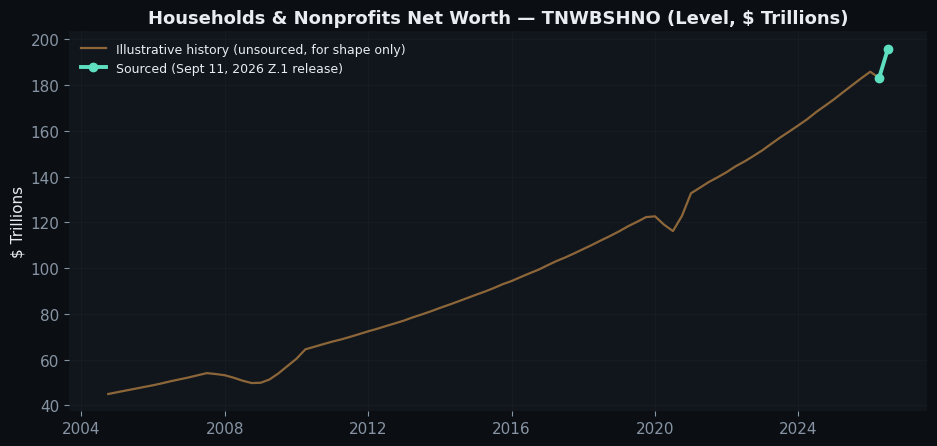

In [11]:
# --- Net worth time series ---
fig, ax = plt.subplots(figsize=(9.5, 4.6))
sourced = df[df["data_provenance"] == "sourced"]
illus = df[df["data_provenance"] == "illustrative"]
ax.plot(df["date"], df["value_trillions"], color=ACCENT2, linewidth=1.6, alpha=0.55,
        label="Illustrative history (unsourced, for shape only)")
ax.plot(sourced["date"], sourced["value_trillions"], color=ACCENT, linewidth=2.8,
        marker="o", markersize=6, label="Sourced (Sept 11, 2026 Z.1 release)")
ax.set_title("Households & Nonprofits Net Worth — TNWBSHNO (Level, $ Trillions)")
ax.set_ylabel("$ Trillions")
ax.grid(True, alpha=0.35, linewidth=0.6)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", frameon=False, fontsize=9)
for s in ax.spines.values(): s.set_visible(False)
savefig(fig, "chart_time_series.png")
plt.show()

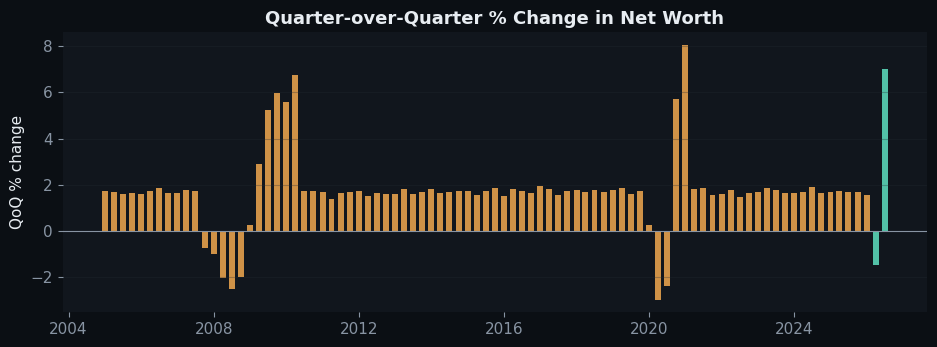

In [12]:
# --- QoQ % change ---
fig, ax = plt.subplots(figsize=(9.5, 3.6))
colors = [ACCENT if p == "sourced" else ACCENT2 for p in df["data_provenance"]]
ax.bar(df["date"], df["qoq_pct_change"], width=60, color=colors, alpha=0.85)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.set_title("Quarter-over-Quarter % Change in Net Worth")
ax.set_ylabel("QoQ % change")
ax.grid(True, alpha=0.3, axis="y")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for s in ax.spines.values(): s.set_visible(False)
savefig(fig, "chart_qoq_change.png")
plt.show()

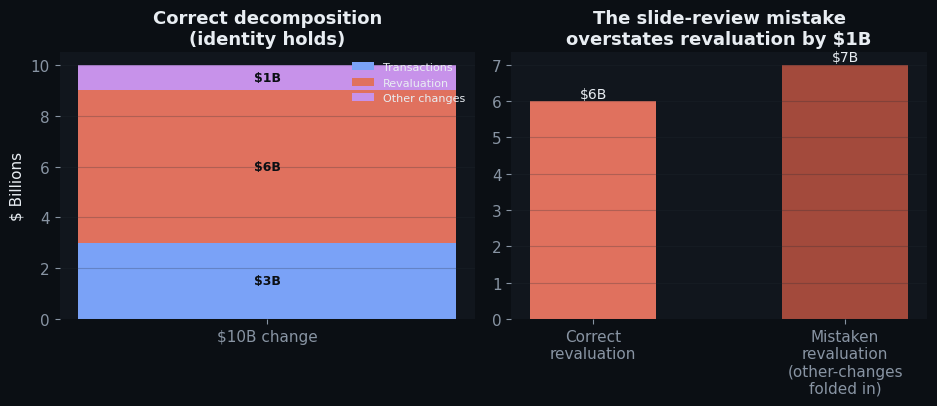

In [13]:
# --- Decomposition + common mistake ---
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
ax = axes[0]
labels = ["Transactions", "Revaluation", "Other changes"]
values = [identity_example["transactions"], identity_example["revaluation_residual"], identity_example["other_changes"]]
colors = [ACCENT3, ACCENT4, ACCENT5]
bottom = 0
for lab, val, col in zip(labels, values, colors):
    ax.bar(["$10B change"], [val], bottom=bottom, color=col, label=lab, width=0.5)
    ax.text(0, bottom + val / 2, f"${val}B", ha="center", va="center", fontsize=9, color=BG, fontweight="bold")
    bottom += val
ax.set_title("Correct decomposition\n(identity holds)")
ax.set_ylabel("$ Billions")
ax.legend(loc="upper right", frameon=False, fontsize=8)
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, alpha=0.25, axis="y")

ax2 = axes[1]
cats = ["Correct\nrevaluation", "Mistaken\nrevaluation\n(other-changes\nfolded in)"]
vals = [mistake_example["correct_revaluation"], mistake_example["mistaken_revaluation"]]
bars = ax2.bar(cats, vals, color=[ACCENT4, "#a34a3c"], width=0.5)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.1, f"${v}B", ha="center", fontsize=10, color=FG)
ax2.set_title(f"The slide-review mistake\noverstates revaluation by ${mistake_example['overstatement']}B")
ax2.grid(True, alpha=0.25, axis="y")
for s in ax2.spines.values(): s.set_visible(False)
savefig(fig, "chart_decomposition.png")
plt.show()

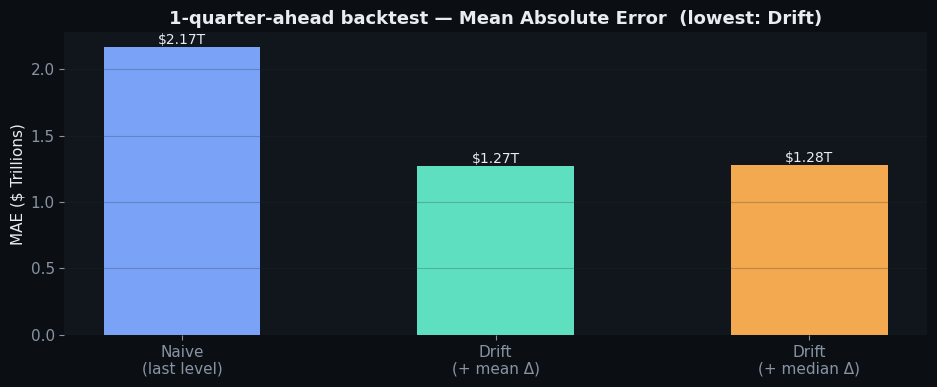

In [14]:
# --- Backtest MAE ---
labels_map = {"naive_last": "Naive\n(last level)", "drift_mean": "Drift\n(+ mean Δ)", "drift_median": "Drift\n(+ median Δ)"}
fig, ax = plt.subplots(figsize=(9.5, 4.0))
names = list(mae_summary.keys())
vals_t = [mae_summary[n] / 1_000_000 for n in names]
colors = [ACCENT3, ACCENT, ACCENT2]
bars = ax.bar([labels_map[n] for n in names], vals_t, color=colors, width=0.5)
for b, v in zip(bars, vals_t):
    ax.text(b.get_x() + b.get_width() / 2, v, f"${v:.2f}T", ha="center", va="bottom", fontsize=10, color=FG)
best = names[int(np.argmin(vals_t))]
ax.set_title(f"1-quarter-ahead backtest — Mean Absolute Error  (lowest: {labels_map[best].splitlines()[0]})")
ax.set_ylabel("MAE ($ Trillions)")
ax.grid(True, alpha=0.25, axis="y")
for s in ax.spines.values(): s.set_visible(False)
savefig(fig, "chart_backtest_mae.png")
plt.show()

## 9. Build the dashboard

Assembles everything above into a single self-contained dark-themed HTML file
(charts embedded as base64 — no internet needed to view it).

In [15]:
import base64

def b64(path):
    return base64.b64encode(path.read_bytes()).decode("ascii")

imgs = {name: b64(OUT / fname) for name, fname in {
    "ts": "chart_time_series.png", "qoq": "chart_qoq_change.png",
    "decomp": "chart_decomposition.png", "mae": "chart_backtest_mae.png",
}.items()}

mae_t = {k: v / 1_000_000 for k, v in mae_summary.items()}
best_model = min(mae_t, key=mae_t.get)
prov = df["data_provenance"].value_counts().to_dict()

checks_html = "".join(
    f'<div class="check {"pass" if v else "fail"}"><span class="dot"></span>{k.replace("_", " ")}</div>'
    for k, v in validation.items() if k != "all_checks_passed"
)

In [16]:
html = f'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Z.1 Net Worth Dashboard — Sept 2026 Release</title>
<meta name="viewport" content="width=device-width, initial-scale=1">
<style>
  :root {{
    --bg: #0b0f14; --panel: #11161d; --panel2: #161d26; --border: #232a34;
    --fg: #e8edf2; --muted: #8894a3; --accent: #5ee0c0; --accent2: #f2a94f;
    --accent3: #7aa2f7; --bad: #e0715e; --good: #5ee0c0;
  }}
  * {{ box-sizing: border-box; }}
  body {{ margin: 0; padding: 0 0 60px 0;
    background: radial-gradient(1200px 600px at 20% -10%, #16202b 0%, var(--bg) 55%);
    color: var(--fg); font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Inter, Roboto, sans-serif; }}
  header {{ padding: 36px 40px 22px 40px; border-bottom: 1px solid var(--border); }}
  header .eyebrow {{ color: var(--accent); font-size: 12px; letter-spacing: .14em; text-transform: uppercase; font-weight: 700; }}
  header h1 {{ margin: 6px 0 8px 0; font-size: 28px; letter-spacing: -0.01em; }}
  header p {{ margin: 0; color: var(--muted); font-size: 14px; max-width: 800px; line-height: 1.5; }}
  .wrap {{ padding: 28px 40px; max-width: 1240px; margin: 0 auto; }}
  .kpis {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 16px; margin-bottom: 28px; }}
  .kpi {{ background: linear-gradient(180deg, var(--panel2), var(--panel)); border: 1px solid var(--border); border-radius: 14px; padding: 18px 20px; }}
  .kpi .label {{ color: var(--muted); font-size: 12px; text-transform: uppercase; letter-spacing: .06em; }}
  .kpi .value {{ font-size: 26px; font-weight: 700; margin-top: 6px; }}
  .kpi .sub {{ color: var(--muted); font-size: 12px; margin-top: 4px; }}
  .kpi.accent .value {{ color: var(--accent); }}
  .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 20px; }}
  @media (max-width: 900px) {{ .grid {{ grid-template-columns: 1fr; }} }}
  .card {{ background: var(--panel); border: 1px solid var(--border); border-radius: 16px; padding: 18px; overflow: hidden; }}
  .card.full {{ grid-column: 1 / -1; }}
  .card img {{ width: 100%; display: block; border-radius: 8px; }}
  .card h2 {{ font-size: 14px; margin: 2px 0 14px 4px; color: var(--fg); font-weight: 600; text-transform: uppercase; letter-spacing: .04em; }}
  .card .note {{ margin: 12px 4px 0 4px; color: var(--muted); font-size: 12.5px; line-height: 1.5; }}
  .badge {{ display: inline-block; padding: 2px 9px; border-radius: 999px; font-size: 11px; font-weight: 700; letter-spacing: .03em; text-transform: uppercase; }}
  .badge.sourced {{ background: rgba(94,224,192,0.15); color: var(--accent); border: 1px solid rgba(94,224,192,0.35); }}
  .badge.illustrative {{ background: rgba(242,169,79,0.15); color: var(--accent2); border: 1px solid rgba(242,169,79,0.35); }}
  .checks {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px,1fr)); gap: 10px; margin-top: 10px; }}
  .check {{ display: flex; align-items: center; gap: 8px; font-size: 13px; padding: 8px 10px; background: var(--panel2); border: 1px solid var(--border); border-radius: 10px; text-transform: capitalize; }}
  .check .dot {{ width: 8px; height: 8px; border-radius: 50%; flex: none; }}
  .check.pass .dot {{ background: var(--good); box-shadow: 0 0 8px var(--good); }}
  .check.fail .dot {{ background: var(--bad); box-shadow: 0 0 8px var(--bad); }}
  table {{ width: 100%; border-collapse: collapse; font-size: 13.5px; }}
  th, td {{ text-align: left; padding: 9px 10px; border-bottom: 1px solid var(--border); }}
  th {{ color: var(--muted); font-weight: 600; text-transform: uppercase; font-size: 11px; letter-spacing: .04em; }}
  td.num {{ text-align: right; font-variant-numeric: tabular-nums; }}
  tr.best td {{ color: var(--accent); font-weight: 700; }}
  footer {{ padding: 30px 40px; color: var(--muted); font-size: 12px; line-height: 1.6; }}
  footer a {{ color: var(--accent3); }}
</style>
</head>
<body>
<header>
  <div class="eyebrow">Federal Reserve · Z.1 Financial Accounts</div>
  <h1>Household &amp; Nonprofit Net Worth — Bridge, Decomposition &amp; Forecast Dashboard</h1>
  <p>Built on the stock-change identity used by the Financial Accounts of the United States
  (ΔStock = Transactions + Revaluation + Other Changes) — not a black-box model, on purpose.
  Series <b>TNWBSHNO</b> (source ID {SOURCE_ID}), {UNITS}. Two quarters below are directly
  sourced from the September 11, 2026 Z.1 release; the rest of the historical line is
  illustrative and clearly marked.</p>
</header>
<div class="wrap">
  <div class="kpis">
    <div class="kpi accent"><div class="label">Latest Net Worth (2026 Q2)</div>
      <div class="value">${{bridge['latest_net_worth_trillions']:.2f}}T</div>
      <div class="sub">Sourced · Sept 11, 2026 Z.1 release</div></div>
    <div class="kpi"><div class="label">Quarterly Increase</div>
      <div class="value">+${{bridge['quarterly_increase_trillions']:.2f}}T</div>
      <div class="sub">Q1 2026 → Q2 2026</div></div>
    <div class="kpi"><div class="label">Quarterly Growth Rate</div>
      <div class="value">{{bridge['quarterly_growth_pct']:.2f}}%</div>
      <div class="sub">Level-on-level, not annualized</div></div>
    <div class="kpi"><div class="label">Best Backtested Baseline</div>
      <div class="value">{{best_model.replace('_',' ').title()}}</div>
      <div class="sub">MAE ${{mae_t[best_model]:.2f}}T (1Q ahead)</div></div>
  </div>
  <div class="grid">
    <div class="card full">
      <h2>Net Worth Level — Time Series &nbsp; <span class="badge sourced">2 sourced pts</span> <span class="badge illustrative">{{prov.get('illustrative',0)}} illustrative pts</span></h2>
      <img src="data:image/png;base64,{{imgs['ts']}}" alt="time series">
      <div class="note">Teal marks the two quarters reported in the article's source release. Amber is an
      illustrative backfill included only so the notebook has a full history to demo against — replace it
      with a live FRED pull (set <code>FRED_API_KEY</code>) for production use.</div>
    </div>
    <div class="card"><h2>Quarter-over-Quarter % Change</h2>
      <img src="data:image/png;base64,{{imgs['qoq']}}" alt="qoq change"></div>
    <div class="card"><h2>1Q-Ahead Backtest — Mean Absolute Error</h2>
      <img src="data:image/png;base64,{{imgs['mae']}}" alt="backtest mae">
      <table><tr><th>Model</th><th class="num">MAE ($T)</th></tr>
      {{''.join(f'<tr class="{{"best" if k==best_model else ""}}"><td>{{k.replace("_"," ").title()}}</td><td class="num">${{v:.2f}}T</td></tr>' for k, v in mae_t.items())}}
      </table></div>
    <div class="card full"><h2>Stock-Change Identity — Decomposition &amp; the Common Mistake</h2>
      <img src="data:image/png;base64,{{imgs['decomp']}}" alt="decomposition">
      <div class="note">Teaching example (not sourced from the Sept 2026 release): $100B → $110B, with $3B of
      net transactions and a $1B documented classification adjustment. Solving the identity gives $6B of
      revaluation. Subtracting only transactions from the stock change mislabels $7B as revaluation, silently
      folding the $1B classification adjustment into the residual.</div></div>
    <div class="card"><h2>Revision / Vintage-Mixing Pitfall</h2>
      <table>
        <tr><td>Mixing old + new vintage</td><td class="num">${{vintage_example['mixed_vintage_change']:.0f}}T</td></tr>
        <tr><td>Consistent vintage comparison</td><td class="num">${{vintage_example['consistent_vintage_change']:.0f}}T</td></tr>
        <tr class="best"><td>Distortion from mixing vintages</td><td class="num">${{vintage_example['distortion_from_mixing_vintages']:.0f}}T</td></tr>
      </table>
      <div class="note">Comparing a revised prior quarter against an unrevised one manufactures part of the
      apparent growth story. Always diff within one release vintage.</div></div>
    <div class="card"><h2>Pipeline Validation — "Break It on Purpose" Checks</h2>
      <div class="checks">{{checks_html}}</div>
      <div class="note">A passing check means the pipeline correctly detected an injected problem — it does
      not certify that any economic interpretation drawn from the data is correct.</div></div>
  </div>
</div>
<footer>
  Source: Board of Governors of the Federal Reserve System (US), Households and Nonprofit Organizations;
  Net Worth, Level [TNWBSHNO], retrieved from FRED, Federal Reserve Bank of St. Louis
  (<a href="https://fred.stlouisfed.org/series/TNWBSHNO">fred.stlouisfed.org/series/TNWBSHNO</a>).
  Generated {{metrics['generated_at']}}. Data mode: <b>{{source_mode}}</b>.
</footer>
</body>
</html>
'''

(OUT / "z1_dashboard.html").write_text(html, encoding="utf-8")
print("Dashboard written to:", OUT / "z1_dashboard.html")

Dashboard written to: /home/claude/z1_project/z1_outputs/z1_dashboard.html


In [17]:
# Preview the dashboard inline in the notebook
from IPython.display import IFrame
IFrame(src=str(OUT / "z1_dashboard.html"), width="100%", height=900)